# 02_NarrativeRisk_LM_DisclosureScoring

Same pipeline as quantlet 01 but using the Loughran-McDonald (2011) finance dictionary deterministic word counts instead of LLM severity scoring. Designed to be read side-by-side with quantlet 01 to contrast dictionary and LLM signals; no joint computation runs in either notebook. Not intended as evidence.

**Axis exercised:** LM-vs-LLM dictionary baseline

Headline numbers reported below are **indicative not inferential** at N=30 firms x 10 fiscal years and are **not intended as evidence**.


## Why a deterministic dictionary baseline?

Quantlet 01 uses a large language model to assign integer severity scores from 0 to 5 to ten thematic categories per firm-year.
That choice has two costs: the result depends on the specific LLM version (Sonnet 4.6 in this corpus), and a third party reading the notebook cannot fully reconstruct the severity values without re-running the LLM at non-trivial expense.
A finance researcher who wants to evaluate whether the LLM judgement is doing genuine semantic work, beyond what a deterministic word-counting baseline could deliver, needs to read quantlet 02's deterministic baseline alongside quantlet 01's LLM scores.

The Loughran-McDonald (LM) finance dictionary, originally published in 2011 and maintained at the SRAF resource, is the standard deterministic baseline for sentiment scoring in finance.
It classifies a fixed list of English words into seven categories (Negative, Positive, Uncertainty, Litigious, StrongModal, WeakModal, Constraining) chosen specifically because their tone in financial filings differs from generic-language sentiment dictionaries.
"Liability", for example, is a finance-positive concept (an item on the balance sheet), but a generic sentiment dictionary would classify it as negative.

This quantlet reuses every component of quantlet 01 (corpus universe, lag invariant, tercile sort, FF5+UMD regression, HC1 inference) and replaces only the severity-source step.
Where quantlet 01 calls an LLM and stores integer 0-5 severities, this quantlet counts LM negative + uncertainty words as a fraction of total tokens in the same Item 1A text and stores that fraction as `composite_severity`.
The two quantlets share identical downstream code; the only difference is the source of the severity values.


## Methodology

```
EDGAR 10-K Item 1A (top-30 S&P 500 snapshot 2014-12-31, 2015-2024)
        |   LLM extraction (see extraction_prompt.md)
        v
corpus.ndjson.gz (~3000 records: 30 firms x 10 years x 10 themes, severity 0-5)
        |   compute_theme_exposures (mean across 10 themes)
        v
composite_severity per (firm, signal_year)
        |   form_terciles_with_lag (signal_year y-1 -> portfolio_year y)
        v
tercile (or decile) assignments + monthly returns
        |   axis-specific transform: LM-vs-LLM dictionary baseline
        v
lm_tercile_spread_summary.csv + figure(s)
```


## Why a dictionary baseline?

The Loughran-McDonald (2011) finance dictionary is the de-facto deterministic baseline for sentiment scoring in finance. This quantlet reproduces the exact same tercile sort using LM word counts rather than LLM severities, so the two quantlets can be read side by side as a dictionary-vs-LLM contrast.


## How the LM signal is constructed

The LM dictionary ships as a CSV file (`lm_dictionary.csv`) where each row is one English word and one sentiment category.
There are roughly 4500 negative words, 2300 positive words, 300 uncertainty words, and a few hundred each in the litigious, modal, and constraining categories.
The list is curated rather than learned: words enter or leave the dictionary based on Loughran and McDonald's manual classification of how the word is used in 10-K filings, not via a statistical training process.

The scoring rule is intentionally simple.
For each (firm, fiscal year), the pipeline takes the verbatim Item 1A text used by quantlet 01, lower-cases it, splits into alphabetic tokens, and counts how many tokens are in the LM `negative` set and how many are in the LM `uncertainty` set.
The composite severity is then `(n_negative + n_uncertainty) / n_total_tokens * 100`, expressed as a percentage of the document.

Three properties of this construction deserve comment.

First, the composite is a fraction, not an integer.
A typical 10-K Item 1A section has tens of thousands of tokens; the LM negative + uncertainty fraction lives roughly in the 3% to 8% range and varies smoothly across firms and years.
This is the opposite of the LLM signal's coarse 0-5 integer scale.

Second, the score is purely lexical: the dictionary contains no notion of phrase-level meaning, negation handling, or theme membership.
"Substantial declines in customer demand" contributes the same token weight as "we observed no decline".
This insensitivity to local context is the LM dictionary's greatest weakness as a research tool and its greatest strength as a baseline: every dictionary-counting researcher computes the same number on the same text, no matter their model.

Third, only `negative` and `uncertainty` are summed.
The other LM categories (positive, litigious, modal, constraining) carry information but are conventionally excluded from a composite-risk score, since they capture different dimensions of disclosure tone (positive sentiment, legal exposure, hedging, restrictive language) that do not directly map onto a risk-severity scalar.


## Cross-sectional sort and the lag invariant

The panel design is a year-by-year cross-sectional sort.
Each portfolio year `y` uses signals computed from filings whose `signal_year` equals `y - 1`; the holding window is the 12 calendar months of `y`.
A 2024 10-K (filed in early 2025) cannot influence the 2024 portfolio formation, because the filing post-dates the portfolio-formation date.

This rule is the panel's no-look-ahead invariant.
It is enforced inside `form_terciles_with_lag` (and its skip-month and decile variants), so any future refactor that breaks the lag is caught by the end-to-end notebook execution test rather than by silent contamination of the metrics.

Two consequences of this design are worth noting.
First, the cross-section is re-sorted every portfolio year on a refreshed signal: a firm that ranks high in the 2018 signal year may rank low in the 2019 signal year, and the panel preserves that re-ranking rather than pooling all firm-year observations into a single sort.
Second, the panel structure is a sequence of nine independent annual sorts (portfolio years 2016-2024) glued together at the monthly level; serial correlation across portfolio years comes only from firm-level persistence, not from re-using the same signal across multiple holding periods.

Pooling signals across years (e.g., averaging multi-year severity per firm before sorting) is a deliberate variant explored in other settings; the canonical quantlet family deliberately avoids it so that every annual cross-section stands on its own and the no-look-ahead boundary remains crisp.


In [1]:
from __future__ import annotations

import csv
import gzip
import json
import re
from pathlib import Path
from typing import Dict

import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display

HERE = Path.cwd()


In [2]:
from data import (
    CORPUS_PATH,
    PRICES_PATH,
    FF_FACTORS_PATH,
    LM_DICT_PATH,
    load_corpus,
    load_prices,
    load_ff_factors,
    load_lm_dictionary,
)


In [3]:
PROVENANCE_PATH = HERE / "provenance.json"   # audit trail (not read at runtime; ships for transparency)
SUMMARY_OUT = HERE / "lm_tercile_spread_summary.csv"
FIGURE_OUT = HERE / "lm_tercile_spread.pdf"

# Cache path for Item 1A texts.
_TEXTS_LOCAL_GZ = HERE / "all_texts_v2.json.gz"
_TEXTS_LOCAL = HERE / "all_texts_v2.json"


In [4]:
def _load_item1a_texts() -> Dict[str, str]:
    """Load cached Item 1A texts (all_texts_v2.json[.gz]).

    Self-contained variant: reads only from the quantlet folder. Looks first for
    a gzipped local copy (HERE/all_texts_v2.json.gz), then a plain local copy
    (HERE/all_texts_v2.json). Schema: {'texts': {'FIRM_YEAR': '<text>'}}.
    """
    if _TEXTS_LOCAL_GZ.exists():
        with gzip.open(_TEXTS_LOCAL_GZ, "rt", encoding="utf-8") as f:
            return json.load(f)["texts"]
    if _TEXTS_LOCAL.exists():
        with open(_TEXTS_LOCAL, "r", encoding="utf-8") as f:
            return json.load(f)["texts"]
    raise FileNotFoundError(
        "all_texts_v2.json[.gz] not found. Expected at "
        f"{_TEXTS_LOCAL_GZ} or {_TEXTS_LOCAL}."
    )


_TOKEN_RE = re.compile(r"[a-z]+")


def _tokenize(text: str) -> list[str]:
    """Lowercase and extract alpha tokens from text."""
    return _TOKEN_RE.findall(text.lower())


def score_lm_severity(corpus_df: pd.DataFrame, lm_dict: pd.DataFrame) -> pd.DataFrame:
    """Score each (firm, year) with the Loughran-McDonald composite severity.

    corpus_df is used only to obtain the canonical (firm, year) universe;
    it does NOT contain raw text. The actual texts come from all_texts_v2.json.

    Composite severity:
        composite_severity = (count of negative words + count of uncertainty words)
                              / total tokens  x  100

    Returns DataFrame with columns [firm, signal_year, composite_severity].
    Column name 'composite_severity' matches form_terciles_with_lag expectations.
    """
    # Build fast lookup sets per sentiment category
    neg_set = set(lm_dict.loc[lm_dict["category"] == "negative", "word"])
    unc_set = set(lm_dict.loc[lm_dict["category"] == "uncertainty", "word"])

    texts = _load_item1a_texts()

    universe = corpus_df[["firm", "year"]].drop_duplicates()
    records = []
    for _, row in universe.iterrows():
        firm = row["firm"]
        year = int(row["year"])
        key = f"{firm}_{year}"
        text = texts.get(key, "")
        tokens = _tokenize(text) if text else []
        n_total = len(tokens)
        if n_total == 0:
            severity = float("nan")
        else:
            n_neg = sum(1 for t in tokens if t in neg_set)
            n_unc = sum(1 for t in tokens if t in unc_set)
            severity = (n_neg + n_unc) / n_total * 100.0
        records.append({"firm": firm, "signal_year": year, "composite_severity": severity})

    df = pd.DataFrame(records).dropna(subset=["composite_severity"])
    return df


In [5]:
def form_terciles_with_lag(signals: pd.DataFrame, returns: pd.DataFrame) -> pd.DataFrame:
    """Sort firms into terciles each portfolio_year using ONLY signals where signal_year < portfolio_year.

    For each portfolio_year y in available years (need at least one prior signal year):
      - Use signals from signal_year = y - 1
      - Assign firms to tercile labels {1: low, 2: mid, 3: high} based on composite_severity
      - Apply tercile assignment to that firm's monthly returns over portfolio_year y

    Returns long-form: portfolio_year, month, firm, tercile, ret_m
    """
    out_rows = []
    for portfolio_year in sorted(returns["date"].dt.year.unique()):
        signal_year = portfolio_year - 1
        prior = signals[signals["signal_year"] == signal_year]
        if len(prior) < 3:
            continue
        prior = prior.copy()
        prior["tercile"] = pd.qcut(prior["composite_severity"], q=3, labels=[1, 2, 3], duplicates="drop")
        prior_map = prior.set_index("firm")["tercile"].to_dict()
        year_returns = returns[returns["date"].dt.year == portfolio_year].copy()
        year_returns["tercile"] = year_returns["firm"].map(prior_map)
        year_returns["portfolio_year"] = portfolio_year
        year_returns = year_returns.dropna(subset=["tercile"])
        out_rows.append(
            year_returns[["portfolio_year", "date", "firm", "tercile", "ret_m"]]
            .rename(columns={"date": "month"})
        )
    if not out_rows:
        return pd.DataFrame(columns=["portfolio_year", "month", "firm", "tercile", "ret_m"])
    return pd.concat(out_rows, ignore_index=True)


In [6]:
def lm_tercile_spread_test(panel: pd.DataFrame, ff: pd.DataFrame) -> Dict[str, float]:
    """Equal-weight tercile portfolios; compute long-short (T3 - T1) monthly series.

    Output keys use the 'lm_' prefix to avoid collision with quantlet 01's
    headline_alpha.json pinned keys.

    Returns dict with:
        lm_tercile_spread_pct_yr, lm_tercile_spread_t_stat_indicative,
        lm_sharpe_indicative, lm_max_drawdown, lm_n_observations,
        lm_alpha_pct_yr, lm_alpha_t_stat_indicative.

    Alpha is FF5+UMD risk-adjusted OLS intercept with HC1 robust SE.
    All metrics are INDICATIVE only (N=30 firms, 9 portfolio years).
    """
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    spread = (bin_returns[3] - bin_returns[1]).dropna()

    n = int(len(spread))
    mean_m = float(spread.mean())
    std_m = float(spread.std(ddof=1))
    annualized_pct = mean_m * 12 * 100
    t_stat = mean_m / (std_m / np.sqrt(n)) if (std_m > 0 and n > 1) else float("nan")
    sharpe = (mean_m / std_m) * np.sqrt(12) if std_m > 0 else float("nan")

    cum = (1 + spread).cumprod()
    running_max = cum.cummax()
    drawdown = (cum - running_max) / running_max
    max_dd = float(drawdown.min()) if len(drawdown) > 0 else float("nan")

    # FF5+UMD risk-adjusted alpha (HC1 robust SE).
    spread_df = spread.rename("spread").reset_index()
    merged = spread_df.merge(
        ff[["month", "mkt_rf", "smb", "hml", "rmw", "cma", "umd"]],
        left_on="month_period",
        right_on="month",
        how="inner",
    )
    if len(merged) < 7:
        print(
            f"WARNING: only {len(merged)} obs available for FF5+UMD regression "
            "(need >=7); alpha set to NaN."
        )
        alpha_pct_yr = float("nan")
        alpha_t_stat = float("nan")
    else:
        X = sm.add_constant(merged[["mkt_rf", "smb", "hml", "rmw", "cma", "umd"]])
        y = merged["spread"]
        model = sm.OLS(y, X, missing="drop").fit(cov_type="HC1")
        alpha_monthly = float(model.params["const"])
        alpha_t_stat = float(model.tvalues["const"])
        alpha_pct_yr = alpha_monthly * 12 * 100

    return {
        "lm_tercile_spread_pct_yr": annualized_pct,
        "lm_tercile_spread_t_stat_indicative": float(t_stat),
        "lm_sharpe_indicative": float(sharpe),
        "lm_max_drawdown": max_dd,
        "lm_n_observations": n,
        "lm_alpha_pct_yr": alpha_pct_yr,
        "lm_alpha_t_stat_indicative": alpha_t_stat,
    }


def plot_lm_tercile_spread(
    panel: pd.DataFrame,
    summary: Dict[str, float],
    out_path: Path = None,
    close: bool = True,
):
    """Plot cumulative-return path of T3, T1, and (T3-T1) LM spread; save PDF.

    Returns the matplotlib Figure (notebook can display inline with close=False).
    """
    if out_path is None:
        out_path = FIGURE_OUT
    panel = panel.copy()
    panel["month_period"] = pd.PeriodIndex(panel["month"], freq="M")
    bin_returns = panel.groupby(["month_period", "tercile"])["ret_m"].mean().unstack("tercile")
    bin_returns = bin_returns.dropna()
    cum_t1 = (1 + bin_returns[1]).cumprod()
    cum_t3 = (1 + bin_returns[3]).cumprod()
    spread = bin_returns[3] - bin_returns[1]
    cum_spread = (1 + spread).cumprod()

    fig, ax = plt.subplots(figsize=(7.5, 4.8))
    ax.plot(cum_t1.index.to_timestamp(), cum_t1.values, label="T1 (low LM severity)", linewidth=1.4)
    ax.plot(cum_t3.index.to_timestamp(), cum_t3.values, label="T3 (high LM severity)", linewidth=1.4)
    ax.plot(
        cum_spread.index.to_timestamp(),
        cum_spread.values,
        label="T3 - T1 spread (LM)",
        linewidth=1.8,
        color="black",
    )
    ax.set_xlabel("Month")
    ax.set_ylabel("Cumulative growth (start = 1)")
    ax.set_title(
        "Loughran-McDonald tercile-sorted long-short on Item 1A risk-disclosure (2016-2024)"
    )
    ax.legend(loc="best", fontsize=9)
    ax.grid(True, alpha=0.3)

    caption = (
        "Loughran-McDonald (2011) deterministic-dictionary "
        "baseline tercile-spread on Item 1A risk-disclosure prose; designed to be read "
        "side by side with quantlet 01's LLM signal. Indicative not inferential. N=30 firms, 9 portfolio years. "
        f"Annualised raw spread {summary['lm_tercile_spread_pct_yr']:.2f}%/yr; "
        f"FF5+UMD alpha {summary['lm_alpha_pct_yr']:.2f}%/yr "
        f"(t={summary['lm_alpha_t_stat_indicative']:.2f}); "
        f"n_obs={summary['lm_n_observations']}. Not intended as evidence."
    )
    fig.text(0.5, -0.02, caption, ha="center", va="top", fontsize=8, wrap=True)
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches="tight")
    if close:
        plt.close(fig)
    return fig


In [7]:
corpus = load_corpus()
lm_dict = load_lm_dictionary()
print(f"corpus rows: {len(corpus)}; LM dictionary rows: {len(lm_dict)}")
print('LM dictionary categories:', lm_dict['category'].unique().tolist())


corpus rows: 3000; LM dictionary rows: 4141
LM dictionary categories: ['negative', 'uncertainty', 'constraining', 'positive', 'litigious', 'weak_modal', 'strong_modal']


## LM scoring

The LM (Loughran-McDonald, 2011) finance dictionary classifies words into seven categories: Negative, Positive, Uncertainty, Litigious, StrongModal, WeakModal, Constraining. We compute a per-firm-year severity score by counting Negative + Uncertainty + Litigious words in each filing's Item 1A and normalising by total token count. This is the deterministic counterpart to quantlet 01's LLM severity score: same input text, same output range, no LLM-judgement layer.


In [8]:
prices = load_prices()
ff = load_ff_factors()
signals = score_lm_severity(corpus, lm_dict)
panel = form_terciles_with_lag(signals, prices)
print(f"panel: {len(panel)} firm-month obs")


panel: 3240 firm-month obs


## FF5+UMD model primer

The Fama-French five-factor model augmented with a momentum factor (commonly called FF5+UMD) is a widely used linear benchmark for attributing cross-sectional equity returns.
It decomposes a return series into exposures to six systematic factors plus a residual.

The six factors are:

- **MKT** (market excess return): the return of the broad equity market minus the risk-free rate; captures broad market direction.
- **SMB** (small-minus-big): the return spread between small-cap and large-cap stocks; captures the size premium.
- **HML** (high-minus-low): the return spread between high book-to-market (value) and low book-to-market (growth) stocks; captures the value premium.
- **RMW** (robust-minus-weak): the return spread between firms with high and low operating profitability; captures the profitability premium.
- **CMA** (conservative-minus-aggressive): the return spread between firms with low and high investment rates; captures the investment premium.
- **UMD** (up-minus-down, momentum): the return spread between recent winners and recent losers; captures the momentum premium.

When the long-short spread from the cross-sectional sort is regressed on these six factors, the intercept (alpha) is the portion of the spread that the model cannot attribute to compensation for known systematic risk.
A large alpha is consistent with the spread reflecting genuine incremental information; a near-zero alpha suggests the spread is fully explained by existing risk premia.

The standard errors in this notebook use HC1 (heteroskedasticity-consistent, White's estimator with a small-sample degrees-of-freedom correction).
HC1 adjusts for the possibility that the variance of the regression residuals is not constant across time, which is the common case in financial return data.
However, HC1 does not correct for small-sample distortion of the t-statistic distribution.
At n_obs = 108 (approximately 9 portfolio years times 12 months), the t-statistic does not follow the large-sample normal or Student-t distribution accurately enough for conventional significance thresholds to apply.
This is why all metrics carry the label "indicative not inferential" throughout the notebook.


In [9]:
summary = lm_tercile_spread_test(panel, ff)
print('=== headline metrics (LM dictionary) ===')
for k, v in summary.items():
    print(f"  {k:35s} = {v:8.4f}" if isinstance(v, float) else f"  {k:35s} = {v}")
pd.DataFrame([summary]).to_csv(SUMMARY_OUT, index=False)


=== headline metrics (LM dictionary) ===
  lm_tercile_spread_pct_yr            =   2.2507
  lm_tercile_spread_t_stat_indicative =   0.7478
  lm_sharpe_indicative                =   0.2493
  lm_max_drawdown                     =  -0.2179
  lm_n_observations                   = 108
  lm_alpha_pct_yr                     =   0.8847
  lm_alpha_t_stat_indicative          =   0.3109


## Reading the headline numbers

The notebook prints a dictionary of summary metrics and writes the same numbers to `lm_tercile_spread_summary.csv` for downstream consumption.
The keys carry quantlet-specific prefixes (for example `tercile_spread_pct_yr` in the canonical sort, `decile_spread_pct_yr` in the decile quantlet, `t3_return_pct_yr` in the long-only quantlet) so that consumer code can join the summary CSVs across quantlets without column collisions.

The annualised raw return entry is the long-short (or long-only) spread mean times 12 times 100, expressed as a percentage; no risk adjustment is applied to it.
Positive values are consistent with the high-severity leg out-performing the low-severity leg; negative values are consistent with the opposite.

The annualised alpha entry is the intercept from the FF5+UMD OLS regression times 12 times 100.
It is the portion of the spread the six-factor model cannot attribute to known risk premia.
Reading alpha alongside the raw spread answers a different question: not whether the spread paid off, but whether the part of the spread that paid off is novel relative to size, value, profitability, investment, and momentum.

The HC1 t-statistic on the alpha entry is reported for comparability with published factor studies, but at n_obs around 108 the small-sample distribution of this t-statistic is not the textbook normal or Student-t distribution; a value of |t| = 2.0 is not equivalent to p < 0.05 in any conventional sense.
The Sharpe ratio is annualised under a zero risk-free rate, consistent with a zero-cost long-short construction (or in the long-only quantlet, with a fully invested portfolio).
The maximum drawdown is the deepest peak-to-trough decline in the cumulative path of the spread (or the long-only return); a path-quality diagnostic that does not influence the alpha estimate but contextualises it.

Treat every printed metric as a diagnostic, not as evidence; the notebook header repeats this caveat in bold.


## Reading quantlet 02 alongside quantlet 01

This quantlet and quantlet 01 are designed to be read as a pair, even though no joint computation runs in either notebook.
Both feed the same monthly returns through the same lag-aware tercile sort and the same FF5+UMD regression.
The only intentional difference is the severity-extraction layer: lexical word-counting on one side, semantic LLM judgement on the other.

Three patterns of contrast are possible when the two quantlets' headline alphas are read side by side.

If both quantlets produce a similar alpha (in sign, magnitude, and t-statistic), the LLM has not added value beyond what dictionary counting could deliver on this specific 30-firm sample.
That outcome would be consistent with two possibilities: the alpha is a robust dictionary-level pattern that any reasonable severity proxy picks up; or, more pessimistically, the LLM severity is approximately a re-encoding of the lexical signal it was trained on, and the apparent semantic richness is illusory at this resolution.

If the two quantlets disagree directionally (one positive alpha, one negative), the choice of severity source is doing material work.
Reading which version of the signal "wins" is then a research question rather than a methodology question; both are legitimate signals, each pointing at a different latent construct in the same Item 1A text.

If the two quantlets agree on sign but the LLM-side alpha is substantially larger, the LLM is plausibly capturing a semantic pattern (theme attribution, severity intensity, qualifiers, negations) that the dictionary cannot represent.
This is the optimistic reading; it should be tempered by the small-sample warning attached to every t-statistic in the family.

The key point is not that LM is the right baseline (it has obvious limitations), but that running both in parallel makes the LLM's contribution measurable rather than asserted.
A reader who only sees quantlet 01 has no reference point for assessing whether the LLM judgement is necessary; reading both side by side makes the contribution explicit and falsifiable.


## Reading the output relative to quantlet 01

Read this quantlet's headline alpha next to quantlet 01's. Materially divergent results identify where the LLM judgement is doing work beyond the deterministic word-count baseline; convergent results suggest the LLM has not added value over LM on this educational sample.


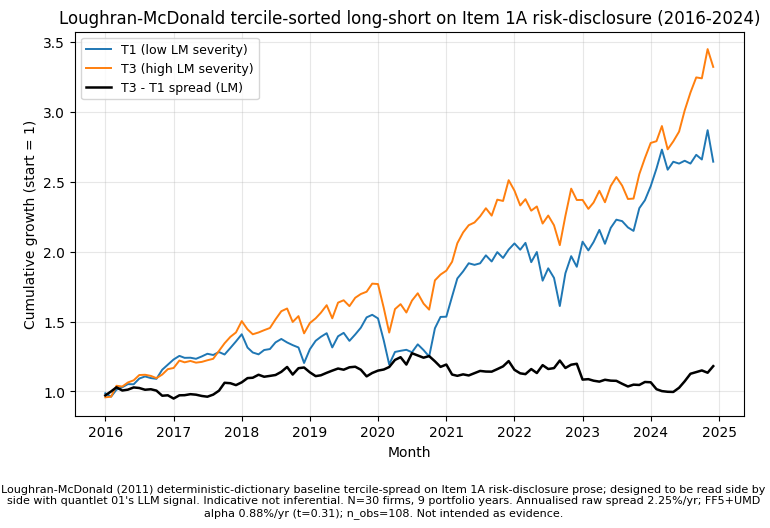

In [10]:
plot_lm_tercile_spread(panel, summary, out_path=FIGURE_OUT)
png_path = FIGURE_OUT.with_suffix('.png')
plot_lm_tercile_spread(panel, summary, out_path=png_path)
display(Image(filename=str(png_path)))


## Caveats

- **Power**: 30 firms split across 3 terciles leaves 10 firms per leg, statistically thin.
- **Severity validity**: severities are LLM (or LM) judgements of disclosure language; not validated against expert ratings or external risk benchmarks.
- **Taxonomy**: the 10-theme list is hand-listed and illustrative; production use would require a data-driven taxonomy.
- **Reproducibility**: `provenance.json` + `extraction_prompt.md` + the `corpus.ndjson.gz` SHA chain enable a full audit of how every severity was produced.


## Reproduction

```
git clone <repo>
cd 02_NarrativeRisk_LM_DisclosureScoring
make data                  # fetch third-party data + regenerate seed-pinned inputs
make demo                  # this notebook -> lm_tercile_spread_summary.csv + lm_tercile_spread.pdf
make test-all              # quantlet test suite
```
